In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, Activation, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from keras.utils import plot_model
from keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2

In [2]:
train_datagen=ImageDataGenerator(rescale=1/255)
test_datagen=ImageDataGenerator(rescale=1/255)

In [3]:
train=train_datagen.flow_from_directory('imagenet-new/train//',class_mode='categorical',target_size=(64,64))

Found 5000 images belonging to 10 classes.


In [4]:
train.class_indices

{'crocodile': 0,
 'fish': 1,
 'fossils': 2,
 'frog': 3,
 'insect': 4,
 'reptiles': 5,
 'scorpion': 6,
 'snake': 7,
 'spider': 8,
 'toad': 9}

In [5]:
train[0]

(array([[[[1.        , 1.        , 0.92549026],
          [1.        , 1.        , 0.9294118 ],
          [1.        , 1.        , 0.9568628 ],
          ...,
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ]],
 
         [[1.        , 0.9921569 , 0.9294118 ],
          [1.        , 0.98823535, 0.94117653],
          [1.        , 1.        , 0.9725491 ],
          ...,
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ]],
 
         [[1.        , 0.9921569 , 0.96470594],
          [1.        , 0.9921569 , 0.9686275 ],
          [0.9921569 , 0.98823535, 0.9803922 ],
          ...,
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ],
          [1.        , 1.        , 1.        ]],
 
         ...,
 
         [[0.98823535, 1.        , 0.9921569 ],
          [0.98823

In [6]:
#Build the model
model = Sequential()
model.add(Input(shape=(64,64,3)))

model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=16,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(32,activation='relu'))
model.add(Dense(10, activation='softmax'))

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       100,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,234 (414.98 KB)

 Trainable params: 106,234 (414.98 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(loss=tf.keras.losses.CategoricalCrossentropy, optimizer='adam', metrics=['accuracy'])

In [9]:
model.fit(train, epochs=32, batch_size=16, verbose =2)

Epoch 1/32
157/157 - 6s - 37ms/step - accuracy: 0.2156 - loss: 2.1230
Epoch 2/32
157/157 - 4s - 29ms/step - accuracy: 0.3560 - loss: 1.8114
Epoch 3/32
157/157 - 4s - 29ms/step - accuracy: 0.4214 - loss: 1.6498
Epoch 4/32
157/157 - 5s - 29ms/step - accuracy: 0.4802 - loss: 1.5155
Epoch 5/32
157/157 - 4s - 29ms/step - accuracy: 0.5282 - loss: 1.3915
Epoch 6/32
157/157 - 4s - 29ms/step - accuracy: 0.5666 - loss: 1.2813
Epoch 7/32
157/157 - 4s - 28ms/step - accuracy: 0.5886 - loss: 1.2031
Epoch 8/32
157/157 - 4s - 28ms/step - accuracy: 0.6450 - loss: 1.0588
Epoch 9/32
157/157 - 4s - 28ms/step - accuracy: 0.6732 - loss: 0.9654
Epoch 10/32
157/157 - 5s - 29ms/step - accuracy: 0.7142 - loss: 0.8596
Epoch 11/32
157/157 - 5s - 29ms/step - accuracy: 0.7414 - loss: 0.7619
Epoch 12/32
157/157 - 4s - 28ms/step - accuracy: 0.7964 - loss: 0.6340
Epoch 13/32
157/157 - 4s - 28ms/step - accuracy: 0.8132 - loss: 0.5602
Epoch 14/32
157/157 - 4s - 28ms/step - accuracy: 0.8458 - loss: 0.4792
Epoch 15/32
157

In [10]:
import cv2
res=dict((v,k) for k,v in train.class_indices.items())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
spider


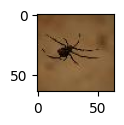

In [15]:
img=plt.imread('imagenet-new/val/images/val_192.jpeg')
plt.figure(figsize=(1,1))
plt.imshow(img)
img=img.reshape(1,64,64,3)
prediction=model.predict(img)
print(res[prediction[0].argmax()])